# Rozlisenie troch tried (rest / left / right)

Trojtriedna uloha: **rest (0)**, **motoricka imaginacia lavej ruky (1)**, **pravej ruky (2)**. Rovnaky retazec ako pri binarnej ulohe (cross-session LOSO, motoricke kanaly, filter bank, recentrovane kovariancie, tangent space), len bez zlucenia tried. Porovnavame **LDA, LR, RF** s aj bez Riemannian Potato.

Navyse rozkladame trojtriedne predikcie na dve ciastkove rozlisenia (rest vs MI a lava vs prava), aby sme videli, kde model straca.

## 1. Nacitanie a predspracovanie

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import mi_pipeline as mi

SESSION_GLOB = "data/session_glob/brainwaves_*_T6s.json"
FIG_DIR = Path("figures"); FIG_DIR.mkdir(exist_ok=True)

covs_by_band, labels, groups, session_ids, channel_names = mi.load_dataset(SESSION_GLOB)

N_CLASSES = 3
CLASS_NAMES = ["rest", "left", "right"]
CHANCE = 1/3                          # nahodna uroven pri 3 triedach

[0] brainwaves_s01_N100_T6s.json: 300 okien
[1] brainwaves_s02_N50_T6s.json: 150 okien
[2] brainwaves_s03_N100_T6s.json: 300 okien
[3] brainwaves_s04_N100_T6s.json: 300 okien
[4] brainwaves_s05_N100_T6s.json: 300 okien
[5] brainwaves_s06_N100_T6s.json: 300 okien
[6] brainwaves_s07_N100_T6s.json: 300 okien

okná po triedach: {'rest': 636, 'left': 651, 'right': 663}  | spolu 1950
motorické kanály: ['C3', 'C4', 'CP3', 'CP4']


## 2. Vyhodnotenie vsetkych konfiguracii

In [12]:
results = mi.run_all_configurations(
    covs_by_band, labels, groups, session_ids, n_classes=N_CLASSES)

rows = mi.summarize(results, class_labels=[0, 1, 2])
mi.print_summary(rows, CLASS_NAMES)

konfigurácia        bal_acc     acc  rec_rest  rec_left rec_right   rej%
------------------------------------------------------------------------
LDA, s Potato         0.730   0.729     0.774     0.724     0.692   3.0
LR, s Potato          0.719   0.718     0.774     0.691     0.692   3.0
RF, s Potato          0.715   0.714     0.788     0.696     0.661   3.0
LR, bez Potato        0.710   0.709     0.750     0.696     0.683   0.0
LDA, bez Potato       0.708   0.708     0.750     0.700     0.674   0.0
RF, bez Potato        0.704   0.703     0.774     0.682     0.656   0.0


## 3. Rozklad na ciastkove rozlisenia
Z trojtriednych predikcii odvodime rest vs MI a lava vs prava - ukaze, ci narocnost spociva v detekcii MI alebo v jej lateralizacii.

In [13]:
decomp = mi.decompose_multiclass(results)
print(f"{'konfiguracia':18s}{'3 triedy':>10s}{'rest/MI':>10s}{'lava/prava':>12s}")
print("-" * 50)
for d in decomp:
    print(f"{d['name']:18s}{d['bal_acc']:>10.3f}{d['rest_vs_mi']:>10.3f}{d['left_vs_right']:>12.3f}")

konfiguracia        3 triedy   rest/MI  lava/prava
--------------------------------------------------
LDA, s Potato          0.730     0.817       0.708
LR, s Potato           0.719     0.806       0.692
RF, s Potato           0.715     0.817       0.678
LR, bez Potato         0.710     0.803       0.690
LDA, bez Potato        0.708     0.807       0.687
RF, bez Potato         0.704     0.808       0.669


/opt/anaconda3/envs/diplomovka/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/opt/anaconda3/envs/diplomovka/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/opt/anaconda3/envs/diplomovka/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/opt/anaconda3/envs/diplomovka/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/opt/anaconda3/envs/diplomovka/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.w

## 4. Robustnost napriec session

In [14]:
mi.print_robustness(rows)
best = rows[0]
print(f"\nNajlepsia konfiguracia: {best['name']}  "
      f"(bal_acc = {best['bal_acc']:.3f}, "
      f"per-session {best['ps_min']:.3f}-{best['ps_max']:.3f}, "
      f"sd = {best['ps_std']:.3f})")

konfigurácia        priemer     sd    min    max
------------------------------------------------
LDA, s Potato         0.724  0.062  0.628  0.800
LR, s Potato          0.713  0.071  0.608  0.800
RF, s Potato          0.712  0.046  0.667  0.774
LR, bez Potato        0.703  0.068  0.608  0.788
LDA, bez Potato       0.703  0.059  0.628  0.798
RF, bez Potato        0.700  0.048  0.643  0.765

Najlepsia konfiguracia: LDA, s Potato  (bal_acc = 0.730, per-session 0.628-0.800, sd = 0.062)


## 5. Grafy do prace

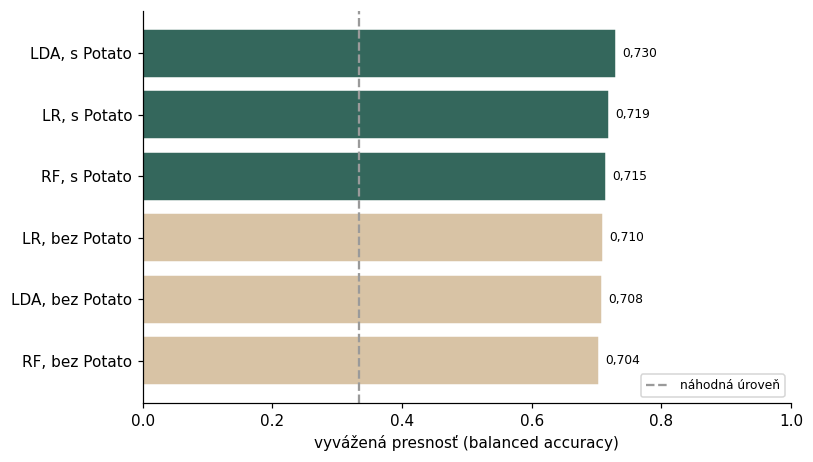

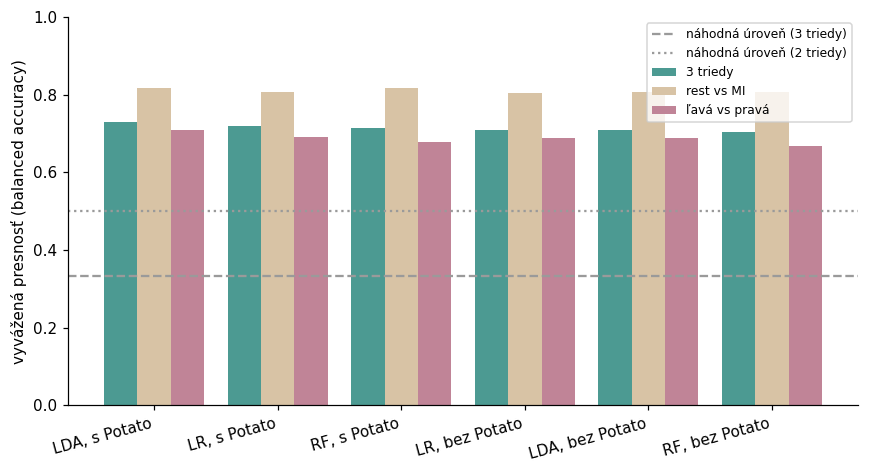

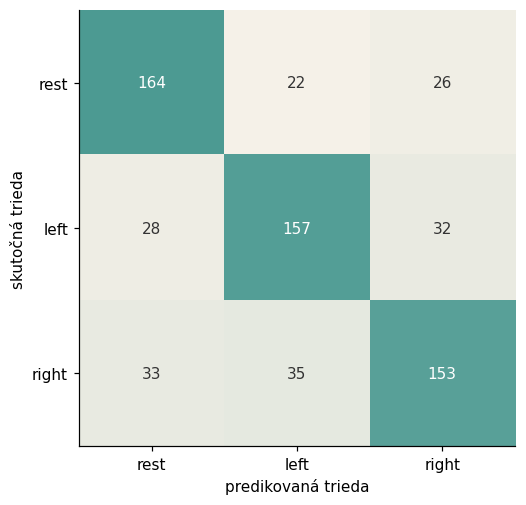

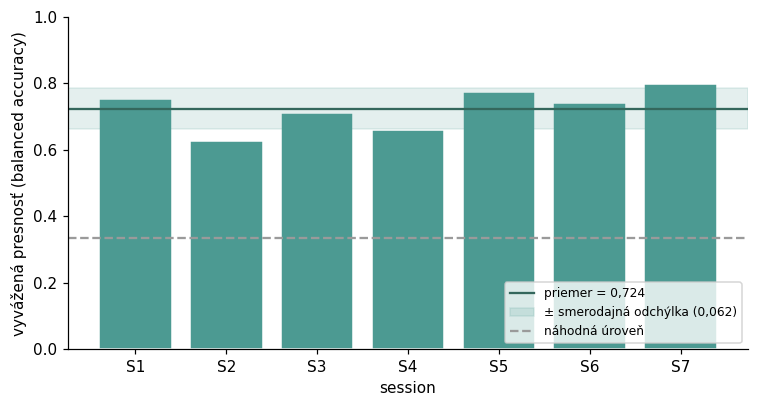

In [15]:
mi.plot_balanced_accuracy(
    rows, chance_level=CHANCE,
    save_path=FIG_DIR / "rlr_balacc.png")

mi.plot_decomposition(decomp, save_path=FIG_DIR / "rlr_decomposition.png")

mi.plot_confusion(
    results[best["name"]]["trial_true"], results[best["name"]]["trial_pred"],
    CLASS_NAMES, save_path=FIG_DIR / "rlr_confusion.png")

mi.plot_per_session(
    best, results, chance_level=CHANCE,
    save_path=FIG_DIR / "rlr_per_session.png")
plt.show()